In [26]:
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

# ------------------- MMD loss with safeguard -------------------
def mmd_loss(x, y, sigma_min=1e-3):
    if x.dim() == 1:
        x = x.unsqueeze(1)
        y = y.unsqueeze(1)

    n, m = x.size(0), y.size(0)

    xx = torch.cdist(x, x, p=2).pow(2)
    yy = torch.cdist(y, y, p=2).pow(2)
    xy = torch.cdist(x, y, p=2).pow(2)

    with torch.no_grad():
        all_d2 = torch.cat([xx.flatten(), yy.flatten(), xy.flatten()])
        sigma_sq = torch.median(all_d2)
        sigma_sq = sigma_sq.clamp(min=sigma_min**2)
        sigma = sigma_sq.sqrt()

    K_xx = torch.exp(-xx / (2 * sigma**2))
    K_yy = torch.exp(-yy / (2 * sigma**2))
    K_xy = torch.exp(-xy / (2 * sigma**2))

    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()

# ------------------- Data loading (simulated pandas DataFrame) -------------------
# Replace this with your actual data loading, e.g. pd.read_csv('file.csv')
# For demonstration, create a DataFrame with a column 'value' containing NaNs

df = pd.read_csv("../data/processed/fwhm_linewidths.csv")


In [27]:
df = df[(df["transmission"] == 60) & (df["power_nW"]==3)]["fwhm"].dropna().reset_index(drop=True).copy()

In [28]:

# Convert to PyTorch tensor (float32)
exp_data = torch.tensor(df, dtype=torch.float32)*100

In [29]:
df

0       0.045822
1       0.025012
2       0.024199
3       0.027339
4       0.036384
          ...   
2621    0.022603
2622    0.018261
2623    0.021339
2624    0.033335
2625    0.036545
Name: fwhm, Length: 2626, dtype: float64

In [30]:
from tqdm import tqdm

# ------------------- Simulated data: start from a uniform distribution -------------------
# Use the same number of points as the cleaned experimental data
torch.manual_seed(42)
sim_data = torch.rand(exp_data.size()[0]) * 2 - 1    # uniform [-1, 1]
sim_data_initial = sim_data.clone()         # save for initial KDE

sim_data.requires_grad = True

# ------------------- KDE before optimisation -------------------
x_grid = np.linspace(-5, 7, 500)
exp_np = exp_data.numpy()
sim_init_np = sim_data_initial.detach().numpy()

kde_exp = gaussian_kde(exp_np)
kde_sim_init = gaussian_kde(sim_init_np)

# ------------------- Optimisation -------------------
optimizer = torch.optim.Adam([sim_data], lr=0.2)



In [31]:

num_steps = 100
for step in tqdm(range(1, num_steps + 1)):
    optimizer.zero_grad()
    loss = mmd_loss(exp_data, sim_data)
    loss.backward()
    optimizer.step()

    if step % 10 == 0:
        print(f"Step {step:3d} | Loss = {loss.item():.6f}")


 10%|█         | 10/100 [00:02<00:25,  3.55it/s]

Step  10 | Loss = 0.343488


 20%|██        | 20/100 [00:05<00:21,  3.80it/s]

Step  20 | Loss = 0.201396


 30%|███       | 30/100 [00:08<00:18,  3.76it/s]

...

Step  80 | Loss = 0.025245


 90%|█████████ | 90/100 [00:25<00:03,  3.29it/s]

Step  90 | Loss = 0.021914


100%|██████████| 100/100 [00:28<00:00,  3.47it/s]

Step 100 | Loss = 0.019525


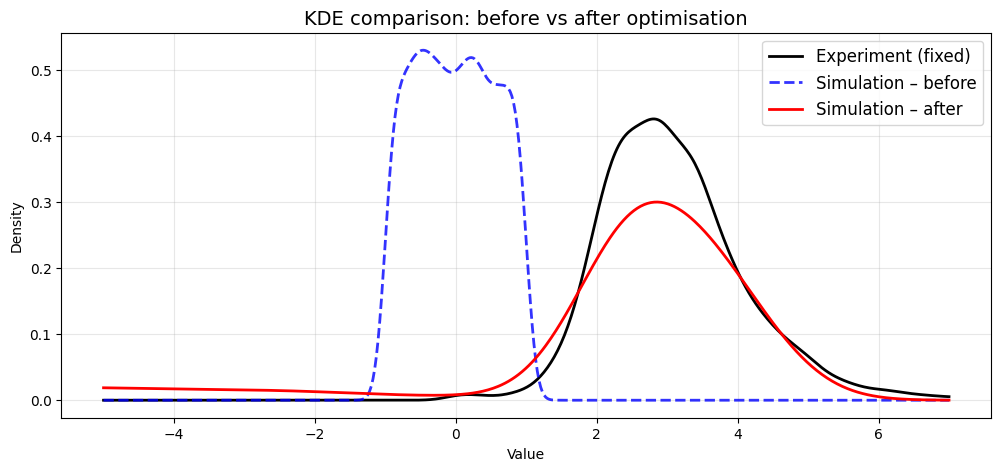

In [32]:

# ------------------- KDE after optimisation -------------------
sim_final_np = sim_data.detach().numpy()
kde_sim_final = gaussian_kde(sim_final_np)

# ------------------- Visualisation -------------------
plt.figure(figsize=(12, 5))

# Plot experiment KDE
plt.plot(x_grid, kde_exp(x_grid), 'k-', linewidth=2, label='Experiment (fixed)')

# Plot initial simulation KDE
plt.plot(x_grid, kde_sim_init(x_grid), 'b--', linewidth=2, alpha=0.8, label='Simulation – before')

# Plot final simulation KDE
plt.plot(x_grid, kde_sim_final(x_grid), 'r-', linewidth=2, label='Simulation – after')

plt.legend(fontsize=12)
plt.title('KDE comparison: before vs after optimisation', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.show()